Vou criar visualizações com cores fixas.

In [31]:
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import ast
import os

In [32]:
''' 

Vou tentar fazer alguma forma de seleção aqui

Minha ideia é fazer uma função que retorna uma função de detecção

Em geral o legal seria fazer alguma região que queremos que as imagens selecionada estejam, farei então a mais facil, um retangulo no espaço RGB
'''



def str_to_list(string_lista):
    """
    Transforma uma string contendo 'np.float64(valor)' em uma lista Python nativa.
    """

    string_limpa = re.sub(r'np\.float64\((.*?)\)', r'\1', string_lista)
    
    lista_real = ast.literal_eval(string_limpa)
    
    return lista_real
        



def detection_func(ini:tuple,fim:tuple):
    rzim,gzim,bzim = ini
    rzao,gzao,bzao = fim

    def func(cor:list):
        if cor in {'Local indefinido','Imagem nao existente'}:
            return False
        
        if type(cor) != list:
            cor = str_to_list(cor)[0]

        R = np.float64(cor[0])*255
        G = np.float64(cor[1])*255
        B= np.float64(cor[2])*255

        if (rzim < R and rzao> R)  and (gzim < G and gzao > G) and (bzim < B and bzao > B):
            return True
        else:
            return False
        
    return func


def color_show(ini:tuple,fim:tuple):
    ''' 
    É necessário ter o matplotlib.pyplot
    
    '''
    rzim,gzim,bzim = ini
    rzao,gzao,bzao = fim

    fig = plt.figure()
    ax = fig.add_subplot(111)

    R,G,B = [],[],[]

    rin = rzim
    gin = gzim
    bin = bzim

    for i in range(10):
        R.append([rzim,gin,bin])
        G.append([rin,gzim,bin])
        B.append([rin,gin,bzim])

        
        
        rzim += (rzao-rzim)/10
        gzim += (gzao-gzim)/10
        bzim += (bzao-bzim)/10


    R = np.array(R)
    G = np.array(G)
    B = np.array(B)


    quadrado = [R/255,G/255,B/255]


    plt.imshow(quadrado)
    plt.axis('off')



In [33]:
tabela = pd.read_csv('../../Data/Obras_Cores.csv')

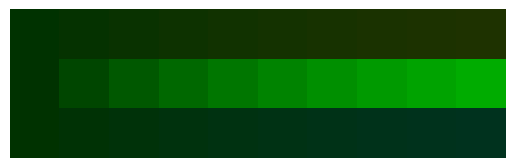

In [34]:
color_show((0,50,0),(50,250,50))

In [35]:
func = detection_func((100,0,0),(250,70,70))
mascara = [func(cor) for cor in tabela['cor']]
util = tabela[mascara]

outra_mascara = [float(quanto) > 0.1 for quanto in util['cor_proporcao']]
util2 = util[outra_mascara]
util2['imagemLocal']
caminho_img = '../../Data/imagens'


#criando o quadro em branco 
img = Image.new('RGB',(3000,2000),color = (255,255,255))


a,b = 0,0

for caminho in util2['imagemLocal']:

    imge = Image.open(os.path.join(caminho_img,caminho))
    imge = imge.resize((300,200), resample=Image.Resampling.BICUBIC)

    img.paste(imge,(a,b))

    a += 300
    a = a%3000
    if a == 0:
        b+=200


img.show()

In [37]:
func = detection_func((0,50,0),(100,250,100))
mascara = [func(cor) for cor in tabela['cor']]
util = tabela[mascara]

outra_mascara = [float(quanto) > 0.8 for quanto in util['cor_proporcao']]
util2 = util[outra_mascara]

caminho_img = '../../Data/imagens'

print(util2['imagemLocal'])
#criando o quadro em branco 
img = Image.new('RGB',(3000,2000),color = (255,255,255))


a,b = 0,0

for caminho in util2['imagemLocal']:

    imge = Image.open(os.path.join(caminho_img,caminho))
    imge = imge.resize((300,200), resample=Image.Resampling.BICUBIC)

    img.paste(imge,(a,b))

    a += 300
    a = a%3000
    if a == 0:
        b+=200


img.show()

7                14741_Retrato_de_Maria_Torquato.jpeg
59                  14853_Paisagem_de_Petr_polis.jpeg
141                                16113_A_Barca.jpeg
200                       16271_Retrato_de_Maria.jpeg
210                       16289_Cabe_a_de_Mulher.jpeg
                            ...                      
1727    20092_Nossa_Senhora_da_Gl_ria_do_Outeiro.jpeg
1737                20108_Paisagem_de_Petr_polis.jpeg
1757                    20167_Menina_com_Cabrito.jpeg
1806                       20374_Negras_da_Bahia.jpeg
1816                            20427_O_Inc_ndio.jpeg
Name: imagemLocal, Length: 106, dtype: str


In [40]:
import pathlib
import json
import re
import csv

CSV_PATH = "../../Data/Obras_Cores.csv"
OBRAS_DIR = pathlib.Path("../../Data/imagens")

_NUM_RE = re.compile(r'np\.float64\(([\d.eE+\-]+)\)')

def parse_cor_dominante(valor):
    """Extrai a primeira cor RGB (0-1) da string da coluna 'cor'."""
    if not isinstance(valor, str) or "nao existente" in valor.lower():
        return None
    numeros = _NUM_RE.findall(valor)
    if len(numeros) < 3:
        return None
    return tuple(float(n) for n in numeros[:3])

data = {}
sem_cor = sem_arquivo = total = 0

with open(CSV_PATH, "r", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    for row in reader:
        total += 1

        # reutiliza a lógica de str_to_list/detection_func: a coluna 'cor'
        # já vem pré-calculada em RGB 0-1, só precisamos converter para 0-255
        cor_rgb01 = parse_cor_dominante(row.get("cor"))
        if cor_rgb01 is None:
            sem_cor += 1
            continue

        nome_arquivo = row.get("imagemLocal", "")
        img_path = OBRAS_DIR / nome_arquivo
        if not nome_arquivo or not img_path.exists():
            sem_arquivo += 1
            continue

        # arredonda para dezena (decimals=-1), igual ao get_average_color da main
        r, g, b = (int(round(c * 255, -1)) for c in cor_rgb01)
        key = str((r, g, b))

        data.setdefault(key, []).append(str(img_path))

print(f"{total} linhas | {sem_cor} sem cor | {sem_arquivo} sem arquivo")
print(f"{sum(len(v) for v in data.values())} obras em {len(data)} cores distintas")

with open("cache.json", "w", encoding="utf-8") as f:
    json.dump(data, f, indent=2, sort_keys=True)

print("cache.json gerado!")

1826 linhas | 251 sem cor | 0 sem arquivo
1575 obras em 644 cores distintas
cache.json gerado!


Cache carregado: 644 cores distintas, 1575 obras
Imagem: 890x560 px | tiles: 10x10 px | total: 4984
  500/4984 tiles (10%)
  1000/4984 tiles (20%)
  1500/4984 tiles (30%)
  2000/4984 tiles (40%)
  2500/4984 tiles (50%)
  3000/4984 tiles (60%)
  3500/4984 tiles (70%)
  4000/4984 tiles (80%)
  4500/4984 tiles (90%)
  4984/4984 tiles (100%)

Pronto! Resultado salvo em 'output.jpg'


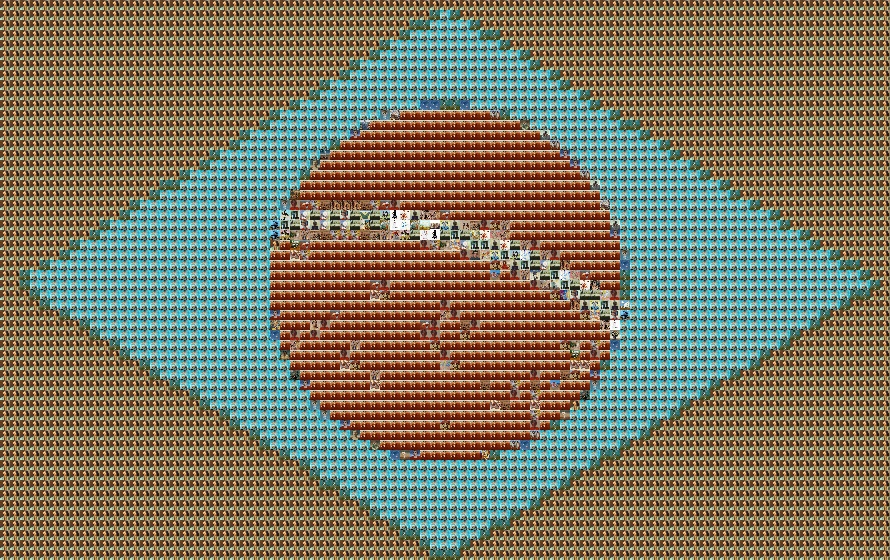

In [41]:
import pathlib
import json
import math
import random

import numpy as np
import cv2
from PIL import Image

# ── configurações ──────────────────────────────────────────────────────────────
INPUT_IMAGE  = "image.jpeg"   # caminho da bandeira
OUTPUT_IMAGE = "output.jpg"
TILE_H, TILE_W = 10, 10       # tamanho de cada tile em pixels
SHOW_PREVIEW = False           # True só se tiver ambiente gráfico
# ───────────────────────────────────────────────────────────────────────────────

def get_average_color(img):
    average_color = np.average(np.average(img, axis=0), axis=0)
    average_color = np.around(average_color, decimals=-1)
    return tuple(int(i) for i in average_color)

def get_closest_color(color, colors):
    cr, cg, cb = color
    min_diff = float("inf")
    closest  = None
    for c in colors:
        r, g, b = eval(c)
        diff = math.sqrt((r-cr)**2 + (g-cg)**2 + (b-cb)**2)
        if diff < min_diff:
            min_diff = diff
            closest  = eval(c)
    return closest

# carrega cache
with open("cache.json", "r", encoding="utf-8") as f:
    cache = json.load(f)

print(f"Cache carregado: {len(cache)} cores distintas, "
      f"{sum(len(v) for v in cache.values())} obras")

# carrega imagem de referência
img = cv2.imread(INPUT_IMAGE)
if img is None:
    raise FileNotFoundError(f"Não consegui abrir '{INPUT_IMAGE}'")

# recorta para múltiplo exato do tile
h, w, _ = img.shape
img = img[: (h // TILE_H) * TILE_H, : (w // TILE_W) * TILE_W]
h, w, _ = img.shape

total_tiles = (h // TILE_H) * (w // TILE_W)
print(f"Imagem: {w}x{h} px | tiles: {TILE_W}x{TILE_H} px | total: {total_tiles}")

# gera o mosaico
n = 0
for y in range(0, h, TILE_H):
    for x in range(0, w, TILE_W):
        n += 1

        trecho = img[y:y+TILE_H, x:x+TILE_W]
        try:
            avg = get_average_color(trecho)
        except Exception:
            continue

        closest = get_closest_color(avg, cache.keys())
        i_path  = random.choice(cache[str(closest)])

        tile = cv2.imread(i_path)
        if tile is None:
            continue
        tile = cv2.resize(tile, (TILE_W, TILE_H))
        img[y:y+TILE_H, x:x+TILE_W] = tile

        if SHOW_PREVIEW:
            try:
                cv2.imshow("Mosaico", img)
                cv2.waitKey(1)
            except cv2.error:
                SHOW_PREVIEW = False

        if n % 500 == 0 or n == total_tiles:
            print(f"  {n}/{total_tiles} tiles ({100*n//total_tiles}%)")

cv2.imwrite(OUTPUT_IMAGE, img)
print(f"\nPronto! Resultado salvo em '{OUTPUT_IMAGE}'")

if SHOW_PREVIEW:
    cv2.destroyAllWindows()

# exibe no próprio notebook
Image.open(OUTPUT_IMAGE)